In [150]:
import rclpy
from rclpy.node import Node
from rosbag2_py import SequentialReader, StorageOptions, ConverterOptions
from sensor_msgs.msg import PointCloud2
import importlib
from rclpy.serialization import deserialize_message
from sensor_msgs_py import point_cloud2 as pc2
import numpy as np
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
%matplotlib widget

In [2]:
reader = SequentialReader()

In [3]:
# Set the storage and converter options
storage_options = StorageOptions(
    uri='/media/asus/backup/zzzzz/ros2/research_thesis/new_ws/bags/rosbag2_2024_07_06-20_29_04',
    storage_id='sqlite3'
)

In [4]:
converter_options = ConverterOptions(
    input_serialization_format='cdr',
    output_serialization_format='cdr'
)

In [5]:
# Open the bag
reader.open(storage_options, converter_options)

[INFO] [1720377920.418872418] [rosbag2_storage]: Opened database '/media/asus/backup/zzzzz/ros2/research_thesis/new_ws/bags/rosbag2_2024_07_06-20_29_04/rosbag2_2024_07_06-20_29_04_0.db3' for READ_ONLY.


In [6]:
# Get the list of topics and types
topics_and_types = reader.get_all_topics_and_types()
print("Topics and Types:", topics_and_types)

Topics and Types: [<rosbag2_py._storage.TopicMetadata object at 0x739f582d9730>, <rosbag2_py._storage.TopicMetadata object at 0x739f58228f70>, <rosbag2_py._storage.TopicMetadata object at 0x739f41e2b430>, <rosbag2_py._storage.TopicMetadata object at 0x739f41e29030>, <rosbag2_py._storage.TopicMetadata object at 0x739f41e29b30>, <rosbag2_py._storage.TopicMetadata object at 0x739f41e2a630>, <rosbag2_py._storage.TopicMetadata object at 0x739f41e2b830>, <rosbag2_py._storage.TopicMetadata object at 0x739f41e2a1b0>, <rosbag2_py._storage.TopicMetadata object at 0x739f41e2aab0>, <rosbag2_py._storage.TopicMetadata object at 0x739f41e28fb0>, <rosbag2_py._storage.TopicMetadata object at 0x739f41e2b8b0>, <rosbag2_py._storage.TopicMetadata object at 0x739f41e2a830>, <rosbag2_py._storage.TopicMetadata object at 0x739f41e28970>, <rosbag2_py._storage.TopicMetadata object at 0x739f41e2b9b0>, <rosbag2_py._storage.TopicMetadata object at 0x739f41e2a6b0>, <rosbag2_py._storage.TopicMetadata object at 0x739f

In [8]:
 # Check if the desired topic is present in the bag
if not any(topic.name == "/velodyne_points" for topic in topics_and_types):
    print("topic not found")
else:
    print("topic found")

topic found


In [59]:
(topic, data, t) = reader.read_next()
print(topic)

/camera/image_raw/theora


In [60]:
while reader.has_next():
    (topic, data, t) = reader.read_next()
    if topic == "/velodyne_points":
        print(f"topic found")
        break

topic found


In [65]:
topic_type = 'sensor_msgs.msg.PointCloud2'

In [66]:
# Dynamically import the message module
msg_module = importlib.import_module(topic_type.rsplit('.', 1)[0])
msg_class = getattr(msg_module, topic_type.rsplit('.', 1)[1])

In [69]:
msg = deserialize_message(data, msg_class)

In [70]:
type(data)

bytes

In [71]:
type(msg)

sensor_msgs.msg._point_cloud2.PointCloud2

In [73]:
pts = pc2.read_points(msg, field_names=["x", "y", "z"], skip_nans=True)

In [116]:
concatenated_pts = np.vstack([pts['x'], pts['y'], pts['z']])

In [117]:
concatenated_pts.shape

(3, 14523)

In [120]:
concatenated_pts[1, :]

array([3.0432796 , 3.025524  , 3.0360231 , ..., 0.34579578, 0.34939402,
       0.34807804], dtype=float32)

In [115]:
concatenated_pts

array([2.414998  , 2.400908  , 2.4092395 , ..., 0.17680334, 0.21217579,
       0.24532549], dtype=float32)

In [149]:
db = DBSCAN(eps=0.4, min_samples=20)
db.fit(concatenated_pts.T)
labels = db.labels_
# print(labels)
# print(len(labels))
# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 9
Estimated number of noise points: 2


*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or R

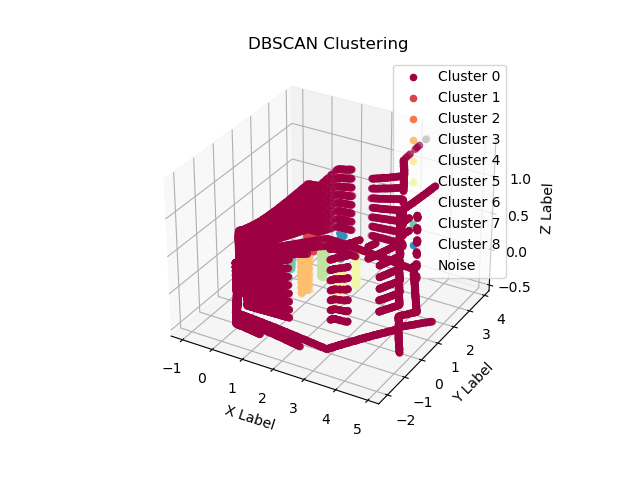

In [152]:
# Plotting the clusters
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# List of unique labels (clusters)
unique_labels = set(labels)

# Assign a color to each label (cluster)
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))

# Plot each cluster
for cluster_label, color in zip(unique_labels, colors):
    if cluster_label == -1:
        # Black used for noise.
        color = 'k'
    
    # Plot points that belong to the current cluster
    cluster_mask = (labels == cluster_label)
    ax.scatter(concatenated_pts[0, cluster_mask], 
               concatenated_pts[1, cluster_mask], 
               concatenated_pts[2, cluster_mask], 
               c=color,
               label=f'Cluster {cluster_label}' if cluster_label != -1 else 'Noise')

ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')

plt.title('DBSCAN Clustering')
plt.legend()
plt.show()

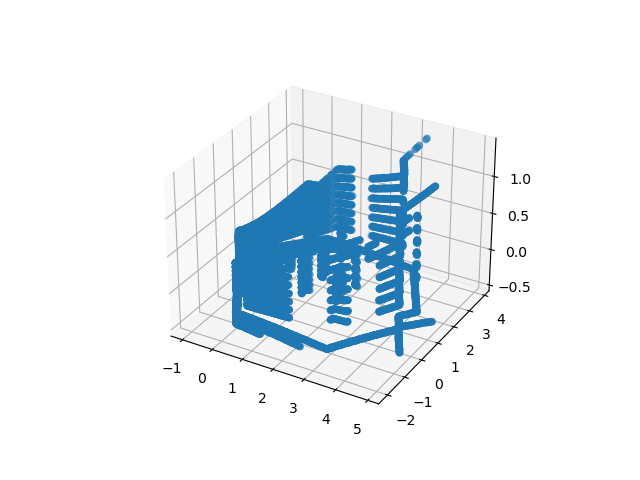

In [151]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
# ax.scatter(pts['x'], pts['y'], pts['z'])
ax.scatter(concatenated_pts[0,:], concatenated_pts[1,:], concatenated_pts[2,:])
plt.show()